
# Analysis 4 — Referral Network Optimization

## Goal
Recommend improved **burn referral pathways** by identifying hospitals that should be prioritized for stronger referral relationships with burn centers.

This analysis combines outputs from previous analyses:

1. **Analysis 1** — Referral gap hospitals  
2. **Analysis 2** — Distance to nearest burn center  
3. **Analysis 3** — Burn center capacity  

The objective is to produce a **ranked intervention list** of hospitals where referral networks should be strengthened.



## Workflow

1. Load outputs from Analyses 1–3  
2. Merge datasets into a unified dataset  
3. Normalize key metrics  
4. Compute a **Final Referral Priority Score**
5. Identify **Top 20 hospitals needing intervention**
6. Produce clean visualizations
7. Export results


In [88]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



## Load Analysis Outputs


In [89]:

analysis1 = pd.read_csv("../outputs/analysis1_referral_results.csv")
analysis2 = pd.read_csv("../outputs/analysis2_distance_results.csv")
analysis3 = pd.read_csv("../outputs/analysis3_capacity_results.csv")

print("Analysis 1 shape:", analysis1.shape)
print("Analysis 2 shape:", analysis2.shape)
print("Analysis 3 shape:", analysis3.shape)


Analysis 1 shape: (498, 7)
Analysis 2 shape: (565, 8)
Analysis 3 shape: (635, 3)



## Merge Datasets
We merge on **HOSPITAL_NAME** since each analysis generated results per hospital.


In [90]:
df = analysis1.merge(
    analysis2,
    on="HOSPITAL_NAME",
    how="left"
)

df = df.merge(
    analysis3[["HOSPITAL_NAME","BURN_BEDS"]],
    left_on="nearest_burn_center",
    right_on="HOSPITAL_NAME",
    how="left",
    suffixes=("","_burn_center")
)

print("Merged dataset shape:", df.shape)
df

Merged dataset shape: (500, 16)


,HOSPITAL_NAME,CITY_x,STATE_FULL_x,adult_gap_flag,peds_gap_flag,dual_trauma_flag,priority_score,CITY_y,STATE_FULL_y,LATITUDE,LONGITUDE,nearest_burn_center,nearest_burn_distance_miles,distance_score,HOSPITAL_NAME_burn_center,BURN_BEDS
0,Alaska Native Medical Center,Anchorage,Alaska,1,1,1,5,Anchorage,Alaska,61.182772,-149.800177,UW Medicine/Harborview Medical Center (UW Medi...,1430.846678,0.999505,UW Medicine/Harborview Medical Center (UW Medi...,40.0
1,Providence Alaska Medical Center/Children's Ho...,Anchorage,Alaska,1,1,1,5,Anchorage,Alaska,61.187168,-149.819439,UW Medicine/Harborview Medical Center (UW Medi...,1431.555391,1.000000,UW Medicine/Harborview Medical Center (UW Medi...,40.0
2,Banner Desert Medical Center/Banner Children's...,Mesa,Arizona,1,1,1,5,Mesa,Arizona,33.390213,-111.878137,Valleywise Health (Arizona Burn Center),9.622539,0.006722,Valleywise Health (Arizona Burn Center),45.0
3,Loma Linda University Medical Center/Loma Lind...,Loma Linda,California,1,1,1,5,Loma Linda,California,34.049112,-117.263435,Arrowhead Regional Medical Center (Edward G. H...,5.274531,0.003684,Arrowhead Regional Medical Center (Edward G. H...,14.0
4,Providence Mission Hospital,Mission Viejo,California,1,1,1,5,Mission Viejo,California,33.561486,-117.665119,Orange County Global Medical Center (Orange Co...,16.434942,0.011480,Orange County Global Medical Center (Orange Co...,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,Gundersen Lutheran Medical Center,La Crosse,Wisconsin,1,0,0,2,La Crosse,Wisconsin,43.795024,-91.246817,University of Wisconsin Hospitals (UW Burn and...,103.709101,0.072445,University of Wisconsin Hospitals (UW Burn and...,11.0
496,SSM Health St. Mary's Hospital Madison,Madison,Wisconsin,1,0,0,2,Madison,Wisconsin,43.058591,-89.404247,University of Wisconsin Hospitals (UW Burn and...,1.863626,0.001302,University of Wisconsin Hospitals (UW Burn and...,11.0
497,ThedaCare Regional Medical Center - Neenah,Neenah,Wisconsin,1,0,0,2,Neenah,Wisconsin,44.187872,-88.453185,Children's Wisconsin (Children's Wisconsin Bur...,82.292348,0.057485,Children's Wisconsin (Children's Wisconsin Bur...,5.0
498,Aurora Medical Center Summit,Summit,Wisconsin,1,0,0,2,Summit,Wisconsin,43.065674,-88.467214,Children's Wisconsin (Children's Wisconsin Bur...,22.586214,0.015777,Children's Wisconsin (Children's Wisconsin Bur...,5.0



## Normalize Metrics

To combine different metrics into one score we normalize them.

Metrics used:

• Distance to nearest burn center  
• Referral gap priority score  
• Burn center capacity pressure


In [91]:

# Normalize distance (higher distance = worse access)
df["distance_score"] = (
    df["nearest_burn_distance_miles"] /
    df["nearest_burn_distance_miles"].max()
)

display(df["BURN_BEDS"])

df["BURN_BEDS"] = df["BURN_BEDS"].fillna(0)
df["capacity_score"] = 1 - (
    df["BURN_BEDS"] / df["BURN_BEDS"].max()
)

df[["distance_score","capacity_score"]]


0      40.0
1      40.0
2      45.0
3      14.0
4       7.0
       ... 
495    11.0
496    11.0
497     5.0
498     5.0
499    11.0
Name: BURN_BEDS, Length: 500, dtype: float64

,distance_score,capacity_score
0,0.999505,0.595960
1,1.000000,0.595960
2,0.006722,0.545455
3,0.003684,0.858586
4,0.011480,0.929293
...,...,...
495,0.072445,0.888889
496,0.001302,0.888889
497,0.057485,0.949495
498,0.015777,0.949495



## Compute Final Referral Priority Score

Weights:

| Factor | Weight |
|------|------|
Distance to burn center | 0.40 |
Referral gap severity | 0.40 |
Burn center capacity | 0.20 |


In [92]:

df["final_priority_score"] = (
    df["distance_score"] * 0.4 +
    df["priority_score"] * 0.4 +
    df["capacity_score"] * 0.2
)

df = df.sort_values("final_priority_score", ascending=False)

df[["HOSPITAL_NAME","final_priority_score"]]


,HOSPITAL_NAME,final_priority_score
1,Providence Alaska Medical Center/Children's Ho...,2.519192
0,Alaska Native Medical Center,2.518994
39,Sanford Medical Center Fargo,2.225668
48,Sanford USD Medical Center,2.220326
22,Baystate Medical Center,2.218157
...,...,...
470,Primary Children's Hospital,NaN
478,Children's Hospital of The King's Daughters,NaN
484,Madigan Army Medical Center Joint Base Lewis,NaN
485,MultiCare Mary Bridge Children's Hospital and ...,NaN



## Identify Top 20 Hospitals Requiring Referral Network Improvements


In [93]:

top10 = df.nlargest(10, "final_priority_score")

top10[[
    "HOSPITAL_NAME",
    "STATE_FULL_x",
    "nearest_burn_center",
    "nearest_burn_distance_miles",
    "final_priority_score"
]]


,HOSPITAL_NAME,STATE_FULL_x,nearest_burn_center,nearest_burn_distance_miles,final_priority_score
1,Providence Alaska Medical Center/Children's Ho...,Alaska,UW Medicine/Harborview Medical Center (UW Medi...,1431.555391,2.519192
0,Alaska Native Medical Center,Alaska,UW Medicine/Harborview Medical Center (UW Medi...,1430.846678,2.518994
39,Sanford Medical Center Fargo,North Dakota,Hennepin Healthcare/Hennepin Healthcare Childr...,214.773390,2.225668
48,Sanford USD Medical Center,South Dakota,CHI Health St. Elizabeth Regional Burn Center,188.425516,2.220326
22,Baystate Medical Center,Massachusetts,Rhode Island Hospital/Hasbro Children's Hospit...,64.982581,2.218157
33,Albany Medical Center,New York,Bridgeport Hospital (The Connecticut Burn Center),105.873577,2.211401
8,Memorial Regional Hospital/Joe DiMaggio Childr...,Florida,Jackson Memorial Hospital (Miami Burn Center),15.869908,2.204434
28,Dartmouth-Hitchcock Medical Center,New Hampshire,The University of Vermont Medical Center (Univ...,72.045930,2.201949
12,OSF St. Francis Medical Center/OSF Children's ...,Illinois,Memorial Medical Center (Regional Burn Center),61.847816,2.201120
29,Cooper University Health Care,New Jersey,Thomas Jefferson University Hospital (Thomas J...,2.275034,2.200636



# Visualization 1 — Priority Intervention List

This chart clearly shows the hospitals that should be addressed first when improving burn referral networks.


C:\Users\arthu\AppData\Local\Temp\ipykernel_33268\1878763354.py:19: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\arthu\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


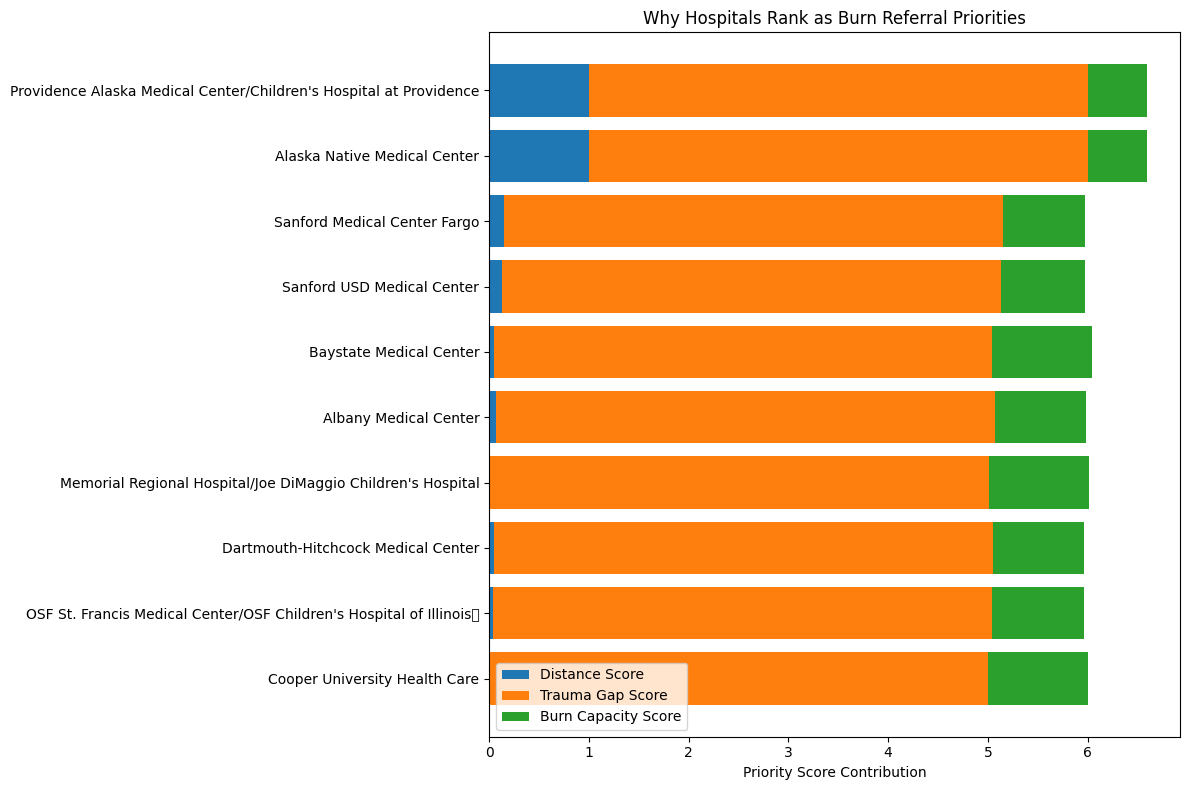

In [94]:
top10_sorted = top10.sort_values("final_priority_score")

labels = top10_sorted["HOSPITAL_NAME"]

distance = top10_sorted["distance_score"]
trauma = top10_sorted["priority_score"]
capacity = top10_sorted["capacity_score"]

plt.figure(figsize=(12,8))

plt.barh(labels, distance, label="Distance Score")
plt.barh(labels, trauma, left=distance, label="Trauma Gap Score")
plt.barh(labels, capacity, left=distance+trauma, label="Burn Capacity Score")

plt.xlabel("Priority Score Contribution")
plt.title("Why Hospitals Rank as Burn Referral Priorities")
plt.legend()

plt.tight_layout()
plt.show()


# Visualization 2 — Distance vs Priority

This scatter plot helps decision‑makers see **which hospitals are both far from burn centers and high priority**.


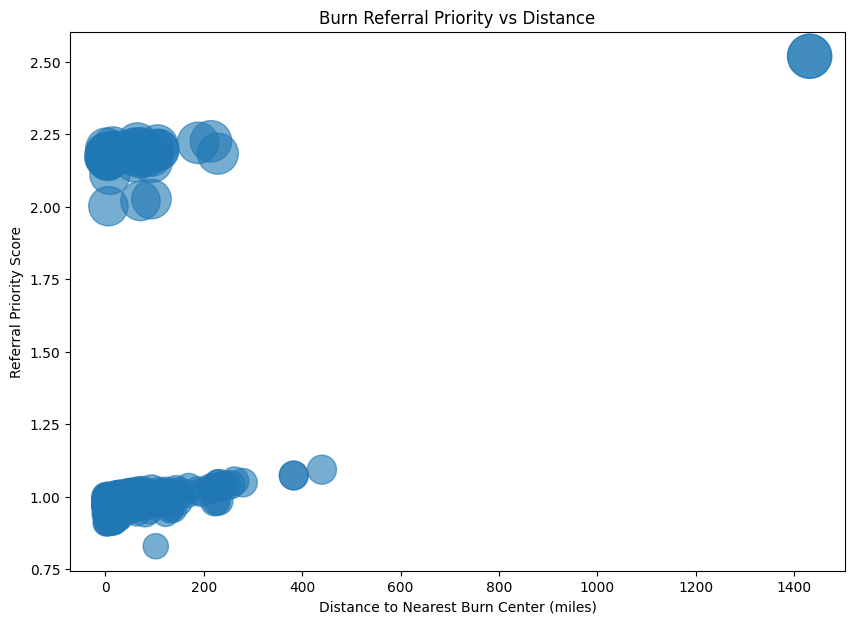

In [95]:
plt.figure(figsize=(10,7))

plt.scatter(
    df["nearest_burn_distance_miles"],
    df["final_priority_score"],
    s=df["final_priority_score"]*400,
    alpha=0.6
)

plt.xlabel("Distance to Nearest Burn Center (miles)")
plt.ylabel("Referral Priority Score")
plt.title("Burn Referral Priority vs Distance")

plt.show()

In [96]:
import folium

# remove hospitals without coordinates
df_map = df.dropna(subset=["LATITUDE", "LONGITUDE"]).copy()

df_map["HOSPITAL_NAME_CLEAN"] = df_map["HOSPITAL_NAME"].str.strip().str.lower()
df_map["nearest_burn_center_clean"] = df_map["nearest_burn_center"].str.strip().str.lower()

burn_lookup = df_map[["HOSPITAL_NAME_CLEAN","LATITUDE","LONGITUDE"]].copy()
burn_lookup = burn_lookup.set_index("HOSPITAL_NAME_CLEAN")

map_center = [df_map["LATITUDE"].mean(), df_map["LONGITUDE"].mean()]
m = folium.Map(location=map_center, zoom_start=5)

# trauma hospitals
for _, row in df_map.iterrows():
    
    folium.CircleMarker(
        location=[row["LATITUDE"], row["LONGITUDE"]],
        radius=4,
        color="blue",
        fill=True,
        fill_opacity=0.7,
        popup=row["HOSPITAL_NAME"]
    ).add_to(m)

# burn centers
#burn_centers = df_map[(df_map["BURN_ADULT"] == 1) | (df_map["BURN_PEDS"] == 1)]
for _, row in df_map.iterrows():

    burn_name = row["nearest_burn_center_clean"]

    if burn_name in burn_lookup.index:

        burn_lat = burn_lookup.loc[burn_name]["LATITUDE"]
        burn_lon = burn_lookup.loc[burn_name]["LONGITUDE"]

        # burn center marker
        folium.Marker(
            location=[burn_lat, burn_lon],
            icon=folium.Icon(color="red"),
            popup="Burn Center: " + row["nearest_burn_center"]
        ).add_to(m)

        # referral line
        folium.PolyLine(
            locations=[
                [row["LATITUDE"], row["LONGITUDE"]],
                [burn_lat, burn_lon]
            ],
            color="orange",
            weight=1,
            opacity=0.5
        ).add_to(m)

m

C:\Users\arthu\AppData\Local\Temp\ipykernel_33268\1270196333.py:16: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\arthu\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


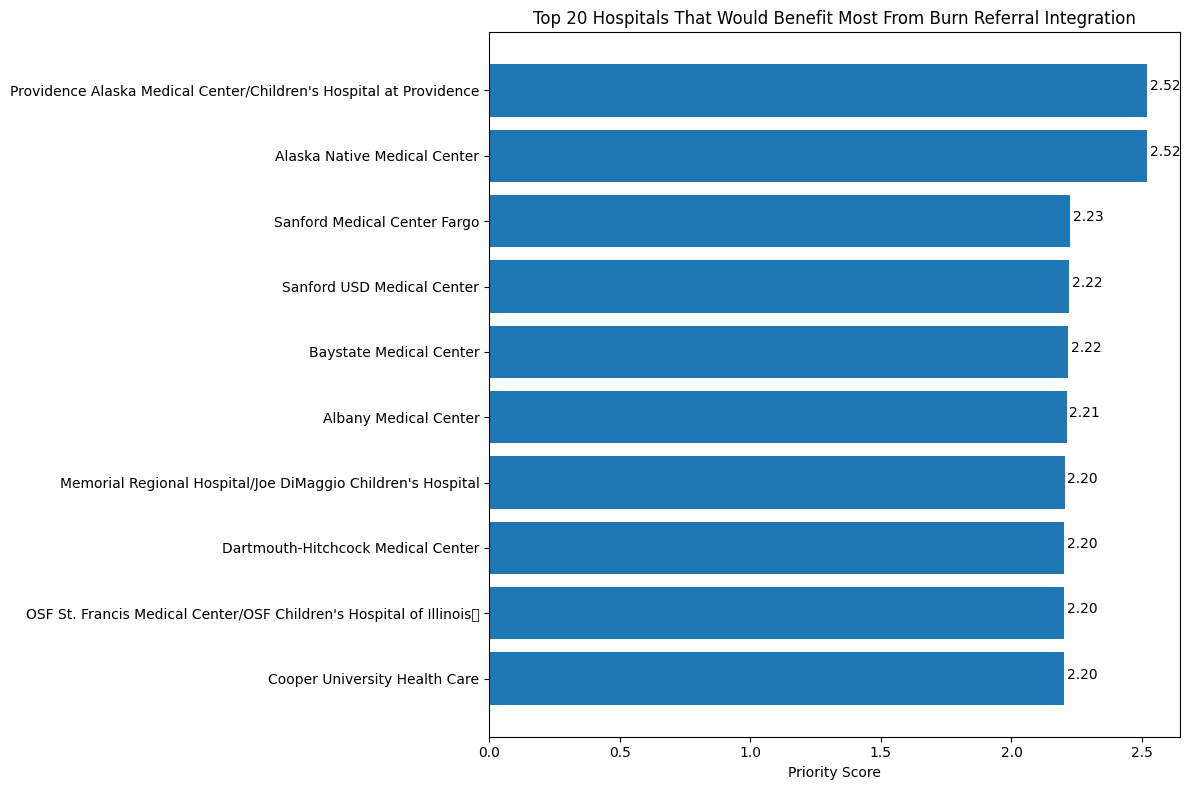

In [97]:
plt.figure(figsize=(12,8))

top10 = top10.sort_values("final_priority_score")

bars = plt.barh(
    top10["HOSPITAL_NAME"],
    top10["final_priority_score"]
)

plt.title("Top 20 Hospitals That Would Benefit Most From Burn Referral Integration")
plt.xlabel("Priority Score")

for i, v in enumerate(top10["final_priority_score"]):
    plt.text(v + 0.01, i, f"{v:.2f}")

plt.tight_layout()
plt.show()


## Export Results


In [98]:

top10.to_csv("../outputs/analysis4_priority_results.csv", index=False)

print("Exported: analysis4_priority_results.csv")

Exported: analysis4_priority_results.csv
